# Day 4.5 — Supervisor Synthesis — You Build the Merge
Four branches now produce findings for nine defects, several describing the same problem under
different ids. The fan-in step must merge, rank, cap, stop — and say what it did. Today's one
hands-on exercise: write `merge_findings`, check it, then use it for the rest of the day.

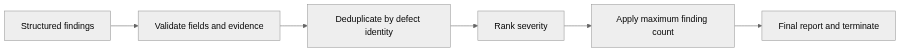

*D14 — validate, deduplicate by defect identity, rank by severity, cap the report, terminate*

### Step 1 — What arrives at the fan-in point

The AST checker plus three specialists. Nothing has been merged, so the same defect appears more
than once under ids nobody shares.

In [ ]:
branch_results = [{"status": "ok", "findings": deterministic_checks(SOURCE)}]
branch_results += [{"status": "ok", "findings": findings}
                   for _role, findings, _usage in fan_out(SOURCE, reviewer_blind)]
labels = ["ast_checker", *SPECIALIST_ROLES]

for label, branch in zip(labels, branch_results):
    print(f"{label:<16} produced {len(branch['findings'])} finding(s)")
incoming = [f for branch in branch_results for f in branch["findings"]]
print("\nTotal arriving at the supervisor:", len(incoming), "for", len(GOLDEN), "real defects\n")

for finding in sorted(incoming, key=lambda f: f.line):
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.id:<26} | {finding.reviewer}")

### Step 2 — Deduplication is harder than matching ids

A static checker calls the line-20 problem `AST-EVAL-20`; a model calls it `MODEL-SEC-20-3`. Same
defect, two ids, two survivors in the report. So the supervisor needs a rule that does not depend
on shared ids — same category, lines close enough to be the same place — and that rule can be
wrong in both directions. Merging must never be silent.

In [ ]:
SEVERITY_RANK = {"low": 1, "medium": 2, "high": 3, "critical": 4}

@dataclass
class SynthesisReport:
    """What the supervisor did, so merging and truncation are never silent."""
    findings: list                 # the findings that survived, ranked
    received: int = 0              # how many arrived from all branches
    merged_duplicates: int = 0     # how many were collapsed into another finding
    kept: int = 0                  # how many were returned
    dropped_over_cap: int = 0      # how many were cut by max_findings
    failed_branches: int = 0       # branches that reported an error instead of findings
    merge_key: str = "location"    # which rule was used

def stronger(candidate, current):
    """Prefer the higher severity; break ties on id so the result is stable across runs."""
    if SEVERITY_RANK[candidate.severity] != SEVERITY_RANK[current.severity]:
        return SEVERITY_RANK[candidate.severity] > SEVERITY_RANK[current.severity]
    return candidate.id < current.id

print("Severity ranking:", SEVERITY_RANK)
print("A SynthesisReport carries the findings AND the accounting:",
      [f.name for f in SynthesisReport.__dataclass_fields__.values()])

### Your turn — write the supervisor

```python
merge_findings(branches, merge_by="location", line_window=1, max_findings=20) -> SynthesisReport
```

`branches` is a list of `{"status": "ok", "findings": [...]}`; a failed branch carries
`{"status": "error", "error": "..."}`. Rules: skip failed branches (one dead specialist must not
erase the others); two findings are the same defect if their **ids** match (`merge_by="id"`) or
they share a **category and are within `line_window` lines** (`merge_by="location"`); when two
merge keep the `stronger` one; rank by severity, then line, then id; cap at `max_findings` and
record how many were dropped.

In [ ]:
def merge_findings(branches, merge_by="location", line_window=1, max_findings=20):
    """YOUR TURN. Return a SynthesisReport: merged, ranked, capped, and fully accounted for."""
    # TODO: collect findings from branches whose status is "ok"; count and announce the failures
    # TODO: for each finding, look for an already-kept finding that is the SAME defect
    # TODO:     merge_by="id"       -> same id
    # TODO:     merge_by="location" -> same category and abs(line difference) <= line_window
    # TODO: on a match: merged_duplicates += 1 and keep the stronger() of the two
    # TODO: otherwise: keep it
    # TODO: rank by (-SEVERITY_RANK[severity], line, id), cap at max_findings, record the rest
    raise NotImplementedError("write the supervisor merge")

print("merge_findings stub defined - fill in the TODOs, then run the check below")

### Behavioural check

Four cases, all deterministic and free. It prints a hint instead of failing while your function is
unfinished.

In [ ]:
def make_finding(id, category, line, severity):
    """A tiny Finding for the checks; the other fields do not affect merging."""
    return Finding(id=id, category=category, line=line, title="check finding", evidence="x",
                   severity=severity, recommendation="fix it", reviewer="check")

def run_merge_checks():
    ok_one = {"status": "ok", "findings": [make_finding("A-1", "security", 15, "critical")]}
    ok_two = {"status": "ok", "findings": [make_finding("B-1", "correctness", 7, "high")]}
    failed = {"status": "error", "error": "timeout"}

    # 1) A failed branch must not erase the others.
    report = merge_findings([ok_one, failed, ok_two])
    assert [f.id for f in report.findings] == ["A-1", "B-1"], report.findings
    assert report.failed_branches == 1 and report.received == 2, report

    # 2) Severity beats id order: Z-1 (critical) must survive and outrank A-9 (low).
    same_place = {"status": "ok", "findings": [make_finding("A-9", "security", 20, "low"),
                                               make_finding("Z-1", "security", 20, "critical")]}
    report = merge_findings([same_place])
    assert [f.id for f in report.findings] == ["Z-1"], "keep the stronger record when two merge"
    assert report.merged_duplicates == 1, report

    # 3) merge_by="id" keeps both, because the ids differ.
    report = merge_findings([same_place], merge_by="id")
    assert [f.id for f in report.findings] == ["Z-1", "A-9"], "id merging leaves cross-reviewer duplicates"

    # 4) The cap must be reported, never silent.
    report = merge_findings([ok_one, ok_two], max_findings=1)
    assert report.kept == 1 and report.dropped_over_cap == 1, report
    print("PASS: failed branches tolerated, duplicates merged by severity, id rule differs, cap reported")

try:
    run_merge_checks()
except NotImplementedError:
    print("Not implemented yet. Fill in merge_findings above, or read the reference solution below and re-run this cell.")

### Reference solution

Read it line by line even if your check passed. **This version is the supervisor used for the
rest of the day.**

In [ ]:
# --- Reference solution ------------------------------------------------------------
def merge_findings(branches, merge_by="location", line_window=1, max_findings=20):
    if merge_by not in {"id", "location"}:
        raise ValueError("merge_by must be 'id' or 'location'")

    incoming, failed = [], 0
    for branch in branches:
        if branch.get("status") != "ok":                  # one dead specialist must not erase the rest
            failed += 1
            print("  supervisor: ignoring failed branch -", branch.get("error"))
            continue
        incoming.extend(branch["findings"])

    kept, merged = [], 0
    for finding in incoming:
        match = None
        for index, existing in enumerate(kept):
            same = (finding.id == existing.id) if merge_by == "id" else (
                finding.category == existing.category
                and abs(finding.line - existing.line) <= line_window)
            if same:
                match = index
                break
        if match is None:
            kept.append(finding)                          # first time we have seen this defect
        else:
            merged += 1                                   # a duplicate: keep the stronger record
            if stronger(finding, kept[match]):
                kept[match] = finding

    ranked = sorted(kept, key=lambda f: (-SEVERITY_RANK[f.severity], f.line, f.id))
    final = ranked[:max_findings]                         # bounded output: the supervisor terminates
    return SynthesisReport(findings=final, received=len(incoming), merged_duplicates=merged,
                           kept=len(final), dropped_over_cap=len(ranked) - len(final),
                           failed_branches=failed, merge_key=merge_by)

run_merge_checks()

### Step 3 — Run both rules on the real branches

Same twelve findings, two rules. The id rule leaves both versions of a defect side by side; the
location rule collapses them.

In [ ]:
by_id = merge_findings(branch_results, merge_by="id")
by_location = merge_findings(branch_results, merge_by="location")

print(f"{'rule':<12}{'received':>10}{'merged':>9}{'kept':>7}{'defects found':>15}{'duplicates':>12}")
print("-" * 65)
for report in (by_id, by_location):
    row = score(report.findings)
    print(f"{report.merge_key:<12}{report.received:>10}{report.merged_duplicates:>9}{report.kept:>7}"
          f"{row['found']:>15}{row['duplicates']:>12}")

print("\nFinal report (location rule), ranked by severity then line:")
for finding in by_location.findings:
    print(f"   {finding.severity:<8} line {finding.line:>3}  {finding.title}  [{finding.reviewer}]")

### Step 4 — The same rule can delete a real defect

Location merging cannot know whether two nearby findings are one defect or two. Here are two
genuinely different security problems, one line apart.

In [ ]:
first = Finding(id="A", category="security", line=15, title="SQL built by string concatenation",
                evidence="query = ... + customer_name", severity="critical",
                recommendation="Parameterise it.", reviewer="sec_a")
second = Finding(id="B", category="security", line=16, title="Result returned without an authorisation check",
                 evidence="return database.execute(query)", severity="high",
                 recommendation="Check the caller.", reviewer="sec_b")

merged = merge_findings([{"status": "ok", "findings": [first, second]}])
print("Two different defects went in :", [f.title for f in (first, second)])
print("Came out of the supervisor    :", merged.kept, "finding(s):", [f.title for f in merged.findings])
print("\nFALSE MERGE: a real defect was deleted by the deduplication rule.")
print("Loosen the rule and you hide defects; tighten it and duplicates survive.")
print("No window is right for every artifact - which is why production systems keep a human here.")

### Step 5 — Capping must not be silent

A supervisor has to terminate, so it caps the report. Truncating silently makes "we found nothing
else" and "we stopped looking" identical.

In [ ]:
capped = merge_findings(branch_results, merge_by="location", max_findings=4)
print("Kept             :", capped.kept, "| dropped over cap:", capped.dropped_over_cap)
for finding in capped.findings:
    print(f"   {finding.severity:<8} line {finding.line:>3}  {finding.title}")
dropped = {f.id for f in by_location.findings} - {f.id for f in capped.findings}
print("\nDropped, and reported as dropped:", len(dropped), "findings on lines",
      sorted(f.line for f in by_location.findings if f.id in dropped))

### Checkpoint

**1. Why can't the supervisor simply deduplicate on the finding id?**

<details><summary>Show answer</summary>

Ids are only shared inside this classroom: the parser says `AST-EVAL-20`, the model says `MODEL-SEC-20-3`. Id merging left 3 duplicates that location merging removed.

</details>

**2. The supervisor caps the report at N findings. What does it owe the reader when it hits that cap?**

<details><summary>Show answer</summary>

The number it dropped. A cap is a legitimate way to terminate; silent truncation hides real findings. `SynthesisReport` records `dropped_over_cap`.

</details>

### Recap

- **Limitation seen:** four branches produced 12 findings for 9 defects, and id merging left duplicates.
- **Layer added:** a bounded fan-in that tolerates a failed branch, merges by category plus line proximity, ranks, caps, and reports what it cut.
- **Evidence:** 12 → 9 findings with 0 duplicates, plus a false merge deleting a real defect.